In [890]:
import numpy as np, torch

# Neuromancer imports: modeling, loss, logging, system dynamics
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.sindy.fx_library import fx_policy_library
from results.utils import *
# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [891]:
# ground truth system model
gt_model = psl.nonautonomous.VanDerPolControl()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = -5.
umax = 5.
xmin = -5.
xmax = 5.


In [892]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device,
                           max_degree=4, add_sqrt=False, add_u_prod=True) for i in range(nx)]

# Print model structures
for fx in fx_models:
    print(fx)


dx0/dt = -0.000*x0 + 0.027*x1 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*x0^3 + -0.001*x0^2*x1 + 0.040*x0*x1^2 + -0.004*x1^3 + 0.013*x0^4 + -0.015*x0^3*x1 + -0.010*x0^2*x1^2 + -0.048*x0*x1^3 + -0.033*x1^4 + -0.021*u_0 + 0.002*x0*u_0 + 0.020*x1*u_0

dx1/dt = -0.000*x1 + 0.027*x0 + -0.041*x0^2 + -0.037*x0*x1 + -0.019*x1^2 + 0.013*x0^3 + -0.001*x0^2*x1 + 0.040*x0*x1^2 + -0.004*x1^3 + 0.013*x0^4 + -0.015*x0^3*x1 + -0.010*x0^2*x1^2 + -0.048*x0*x1^3 + -0.033*x1^4 + -0.021*u_0 + 0.002*x0*u_0 + 0.020*x1*u_0



In [893]:
import os, glob, torch

run_id = 1
models_dir = f"results/tests/dynamics/run_{run_id}/saved_models"   # change root here

for i, model in enumerate(fx_models):
    pattern = os.path.join(models_dir, f"trained_dynamics_x{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for x{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded x{i} from {os.path.basename(ckpt)}")

for fx in fx_models:
    print(fx)

Loaded x0 from trained_dynamics_x0_20250810_153554.pth
Loaded x1 from trained_dynamics_x1_20250810_153554.pth
dx0/dt = 0.000*x0 + 1.001*x1 + 0.000*x0^2 + 0.000*x0*x1 + 0.000*x1^2 + 0.000*x0^3 + 0.000*x0^2*x1 + 0.000*x0*x1^2 + 0.000*x1^3 + 0.000*x0^4 + 0.000*x0^3*x1 + 0.000*x0^2*x1^2 + 0.000*x0*x1^3 + 0.000*x1^4 + 0.000*u_0 + 0.000*x0*u_0 + 0.000*x1*u_0

dx1/dt = 0.884*x1 + -0.984*x0 + 0.000*x0^2 + 0.000*x0*x1 + 0.000*x1^2 + 0.000*x0^3 + -0.991*x0^2*x1 + 0.000*x0*x1^2 + 0.000*x1^3 + 0.000*x0^4 + 0.000*x0^3*x1 + 0.000*x0^2*x1^2 + 0.000*x0*x1^3 + 0.000*x1^4 + 0.986*u_0 + 0.000*x0*u_0 + 0.000*x1*u_0



In [894]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations

run_id = 3
### SPARSE DICTIONARY (SD) MODELS ###
SD_SINDy_policies = [fx_policy_library(nx=nx, nref=1,
                              policy_name=f"u_{k}",
                              seed=1, device=device)
                              for k in range(nu)]


models_dir = f"results/tests/sparse/run_{run_id}/SINDy/saved_models"
for i, model in enumerate(SD_SINDy_policies):
    pattern = os.path.join(models_dir, f"trained_policy_{i}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint for u{i} in {models_dir}")

    ckpt = max(matches, key=os.path.getmtime)
    state_dict = torch.load(ckpt, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"Loaded SD-SINDy policy:  u{i} from {os.path.basename(ckpt)}")


SD_SINDy_policies = [prune_terms_by_name(fp, substring="r_0") for fp in SD_SINDy_policies ]
SD_SINDy_policies = [prune_model(fp) for fp in SD_SINDy_policies]

Loaded SD-SINDy policy:  u0 from trained_policy_0_20250810_084929.pth


In [895]:
def prune_model(model, tol: float = 0.0, *, in_place: bool = False, reinit: bool = False, reinit_std: float = 0.01):
    """
    Prune terms whose |coef| <= tol and remove the corresponding entries from the library.
    Mirrors the 'mask -> active_idx -> slice library + coef' approach in your reference.

    Args:
        model: object with
            - .coef: (n_terms,) or (n_terms, out_dim) tensor / nn.Parameter
            - .library.function_names or .library.functions_names: list[str]
            - optional .library.library: list[callable/objs]
            - optional .library.functions: list[callable]
            - optional .library.shape: tuple
            - optional .library.term_indices: list[...]  (pruned if present)
        tol: threshold; keep a row if any |coef[row]| > tol (for 2D).
        in_place: modify the passed model in place; otherwise returns a deep-copied pruned model.
        reinit: if True, reinitialize the kept coefficients with N(0, reinit_std^2).
        reinit_std: std for reinitialization when reinit=True.

    Returns:
        pruned model (same object if in_place=True, otherwise a deep-copied one).
    """
    m = model if in_place else copy.deepcopy(model)

    with torch.no_grad():
        coef = m.coef
        if coef.ndim == 1:
            mask = torch.abs(coef) > tol                   # (n_terms,)
        elif coef.ndim == 2:
            mask = torch.abs(coef).amax(dim=1) > tol       # (n_terms,)
        else:
            raise ValueError(f"Unsupported coef ndim={coef.ndim}")

        active_idx = torch.nonzero(mask, as_tuple=False).view(-1)
        if active_idx.numel() == 0:
            # keep at least one term to avoid degenerate model
            print("Warning: all terms would be pruned; keeping the largest-magnitude term.")
            if coef.ndim == 1:
                keep_idx = torch.argmax(torch.abs(coef)).view(-1)
            else:
                keep_idx = torch.argmax(torch.abs(coef).amax(dim=1)).view(-1)
            active_idx = keep_idx

        idx = active_idx.tolist()

        # --- slice coefficients
        if reinit:
            new_coef = torch.randn_like(coef[idx, ...]) * reinit_std if coef.ndim == 2 \
                       else torch.randn_like(coef[idx]) * reinit_std
        else:
            new_coef = coef[idx, ...] if coef.ndim == 2 else coef[idx]

        # preserve Parameter-ness and requires_grad
        if isinstance(m.coef, nn.Parameter):
            m.coef = nn.Parameter(new_coef, requires_grad=model.coef.requires_grad)
        else:
            m.coef = new_coef

        # --- resolve names attribute
        names_attr = 'function_names' if hasattr(m.library, 'function_names') else (
                     'functions_names' if hasattr(m.library, 'functions_names') else None)
        if names_attr is not None:
            names = getattr(m.library, names_attr)
            setattr(m.library, names_attr, [names[i] for i in idx])

        # --- prune parallel library structures if present
        if hasattr(m.library, 'library'):
            lib_list = getattr(m.library, 'library')
            setattr(m.library, 'library', [lib_list[i] for i in idx])

        if hasattr(m.library, 'functions'):
            funcs = getattr(m.library, 'functions')
            setattr(m.library, 'functions', [funcs[i] for i in idx])

        if hasattr(m.library, 'term_indices'):
            term_idx = getattr(m.library, 'term_indices')
            setattr(m.library, 'term_indices', [term_idx[i] for i in idx])

        # --- update shape if provided
        if hasattr(m.library, 'shape'):
            old_shape = getattr(m.library, 'shape')
            # assume shape = (n_terms, something)
            setattr(m.library, 'shape', (len(idx), old_shape[1] if len(old_shape) > 1 else 1))

    return m

class VectorizedPolicy(nn.Module):
    """
    Vectorized 2-channel policy:
      u0 basis: [cos(2*x0), cos(2*x1), cos(2*r0), sin(2*r0)]   (4 terms)
      u1 basis: [cos(2*x0), cos(2*x1)]                         (2 terms)

    This module has NO parameters of its own. It reads the .coef Parameters
    from the provided SINDy policy modules and backprop flows into them.
    """
    def __init__(self, sindy_policies, umin=None, umax=None):
        super().__init__()
        assert len(sindy_policies) == 1, "Expected exactly 1 policy (u0)."
        self.policies = sindy_policies   # keep references; no registration
        self.umin = umin
        self.umax = umax

    def forward(self, x: torch.Tensor, r: torch.Tensor) -> torch.Tensor:
        """
        x: (B, 2)  -> [x0, x1]
        r: (B, 2)  -> [r0, r1]  (only r0 used here)
        returns: (B, 2)  -> [u0, u1]
        """
        if x.dim() != 2 or x.size(-1) != 2:
            raise ValueError("x must be of shape (B, 2)")
        if r.dim() != 2 or r.size(-1) != 2:
            raise ValueError("r must be of shape (B, 2)")

        x0 = x[:, 0]
        x1 = x[:, 1]

        # Build feature matrix Phi: (B, 3)
        Phi = torch.stack([
            x0,                         # φ1 = x0
            x0 * torch.cos(x0),         # φ2 = x0*cos(x0)
            x1                          # φ3 = x1
        ], dim=1)

        coef_u0 = self.policies[0].coef

        # u = Phi @ coef  -> (B,)
        u = Phi @ coef_u0
        return torch.clip(u, umin, umax)

In [896]:
SD_SINDy_policies = [prune_model(fp) for fp in SD_SINDy_policies]
copy_SD_SINDy_policies = copy.deepcopy(SD_SINDy_policies)
vectorized_SD_SINDy_policies = VectorizedPolicy(copy_SD_SINDy_policies, umin=umin, umax=umax)
SD_SINDy_policy_node = Node(
            lambda xn, r: vectorized_SD_SINDy_policies(xn,r),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )

## Online Adaptation

#### Update using autograd

#### Noisy system

In [897]:
# Copy the pretrained policy
gt_model = psl.nonautonomous.VanDerPolControl()
van_der_pol_noisy = ode.VanDerPolControl()                   # ODE system equations implemented in PyTorch
# Add parametric noise
van_der_pol_noisy.mu = torch.nn.Parameter(torch.tensor(gt_model.mu + 3.4), requires_grad=False)
gt_model.mu += 3.4
# integrate continuous time ODE# integrate continuous time ODE
gt_integrator_noisy = integrators.Euler(van_der_pol_noisy, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator_noisy, ['xn', 'u'], ['xn'], name='model')

gt_sindy_policy_noisy = copy.deepcopy(System([SD_SINDy_policy_node,
                       gt_integrator_node]))


#### rollout the old policy on the noisy system

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

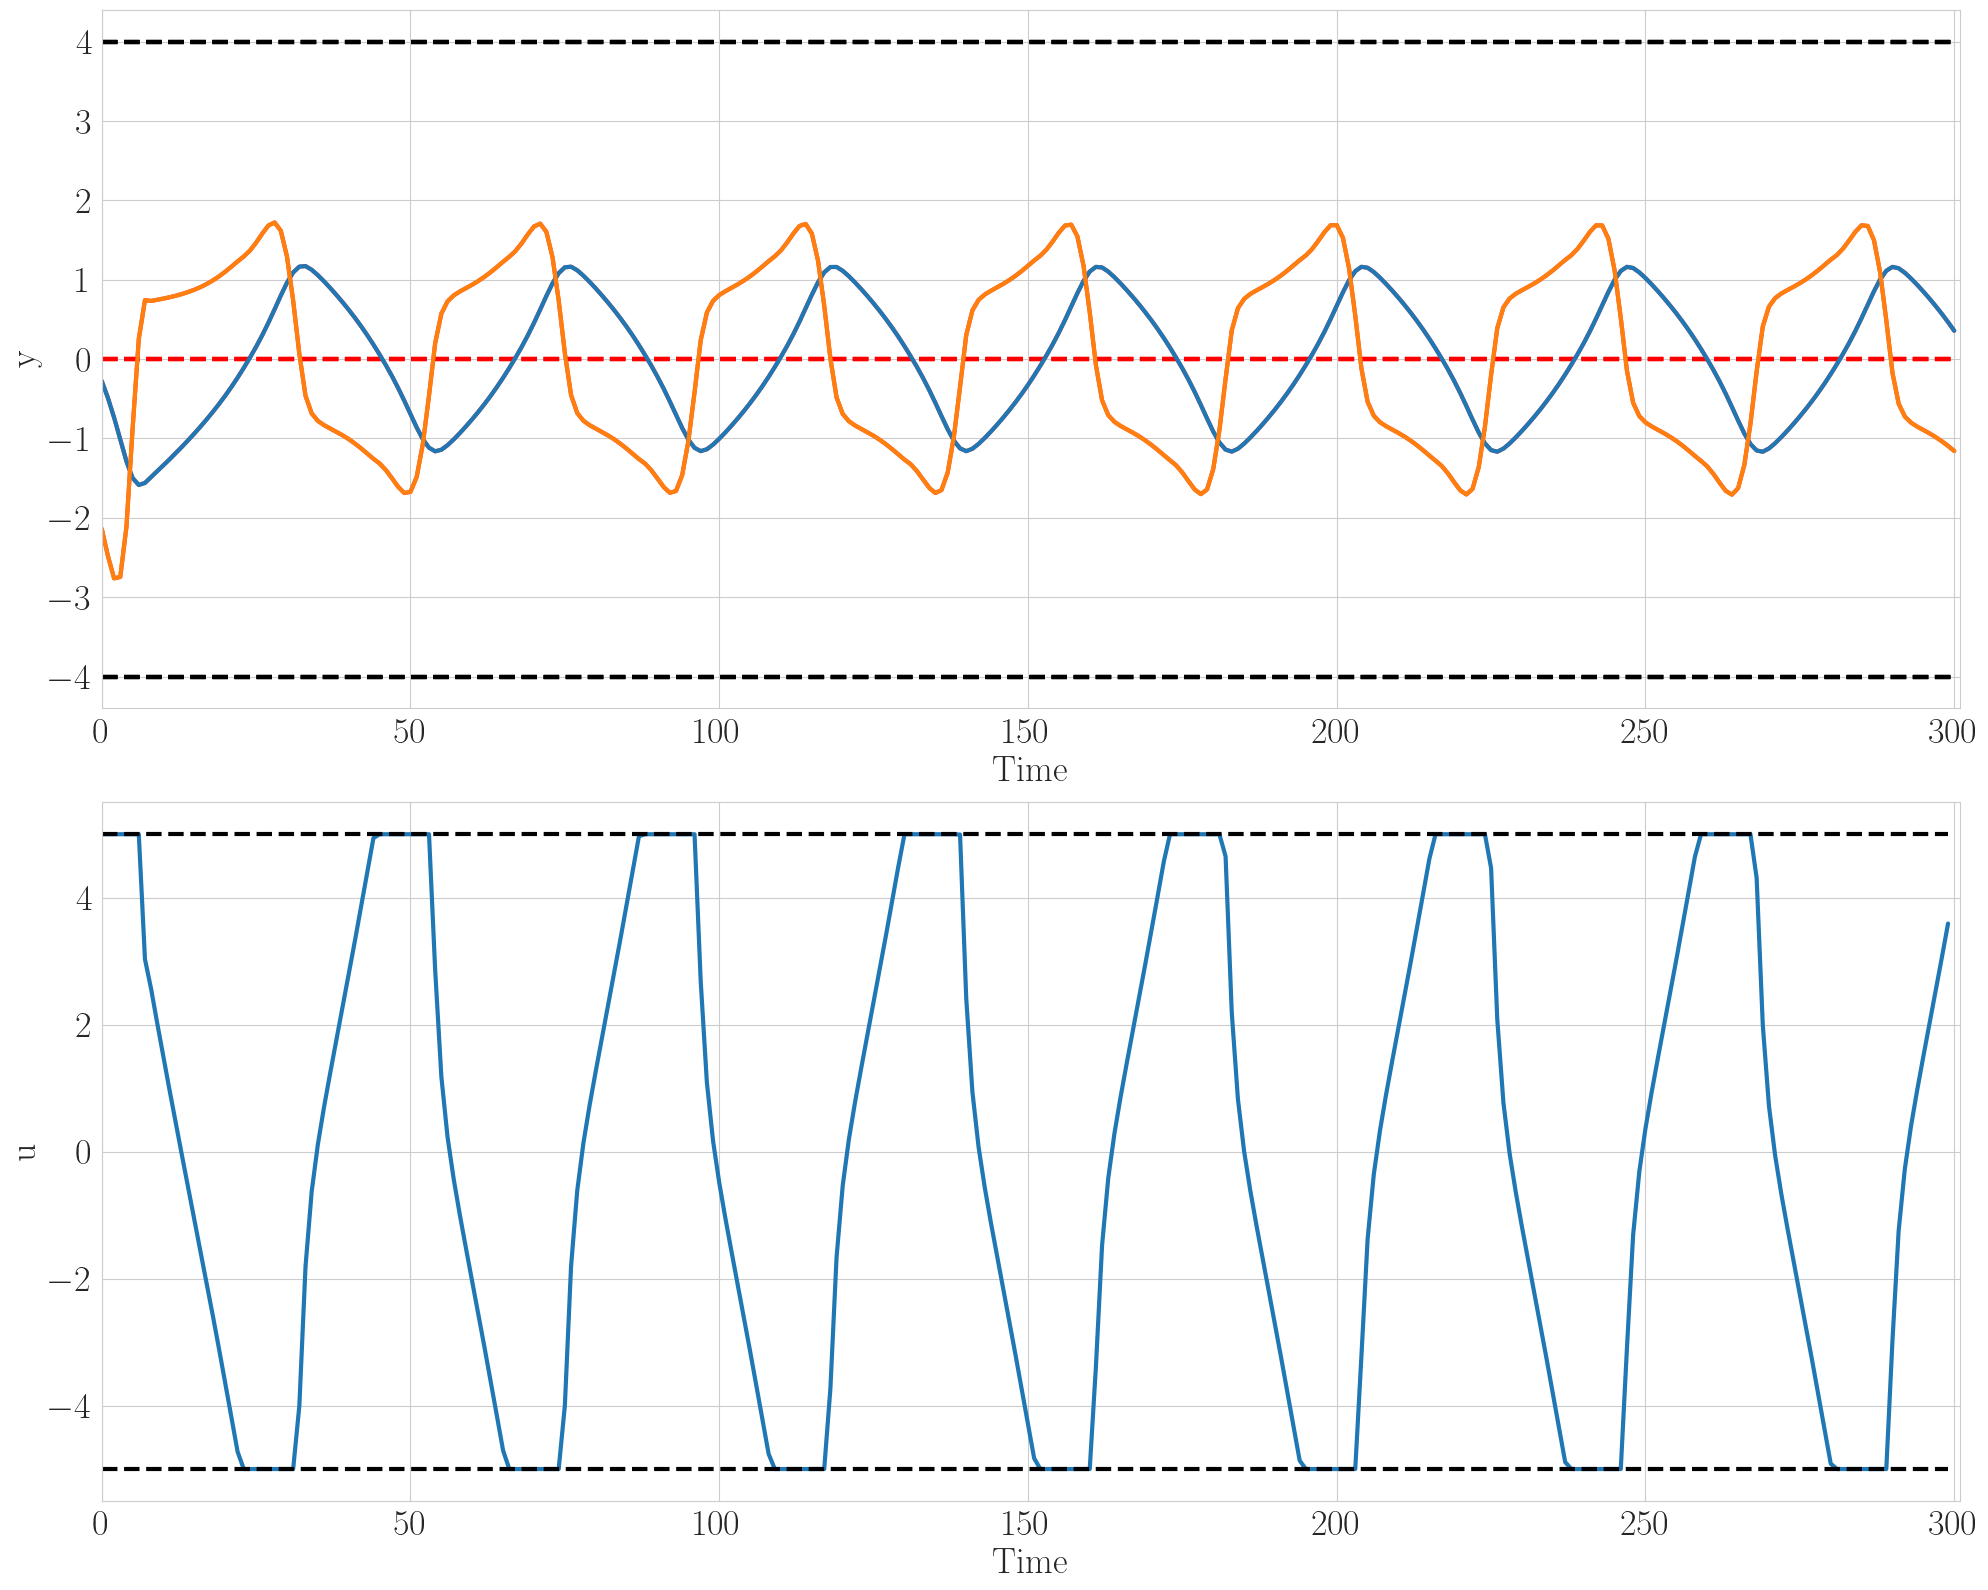

In [898]:
nsteps = 300
seed = 12
torch.manual_seed(seed)
rng = np.random.default_rng(seed)
xmin = -4.
xmax = 4.
# generate reference
torch_ref = torch.zeros(1, nsteps+1, nx, dtype=torch.float32, device=device)
data = {'xn': torch.rand(1, 1, nx, dtype=torch.float32) * (xmax-xmin) + xmin,
        'r': torch_ref}

gt_sindy_policy_noisy.nsteps = nsteps
# perform closed-loop simulation
trajectories_before_adaptation = gt_sindy_policy_noisy(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories_before_adaptation['xn'].detach().reshape(nsteps + 1, nx),
      R=trajectories_before_adaptation['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories_before_adaptation['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

#### Training Loop

In [899]:
import importlib
import SparseDPC.jacobian.vanderpol
importlib.reload(SparseDPC.jacobian.vanderpol)
from SparseDPC.jacobian.vanderpol import build_symbolic_jacobian

In [900]:
jac_sym  = build_symbolic_jacobian(f_dyn_rows=fx_models,
                                   policies=copy_SD_SINDy_policies,
                                   umin=umin, umax=umax)

In [901]:
for i in range(nx):
    for j in range(len(SD_SINDy_policies[0].coef)):
        print(f"Derivative for coefficient {j} in f_{i}(x,u) : ",jac_sym.expr[i,j])

Derivative for coefficient 0 in f_0(x,u) :  0.987436552229667*x_0
Derivative for coefficient 1 in f_0(x,u) :  0.987436552229667*x_0*cos(x_0)
Derivative for coefficient 2 in f_0(x,u) :  0.987436552229667*x_1
Derivative for coefficient 0 in f_1(x,u) :  0.986063122749329*x_0
Derivative for coefficient 1 in f_1(x,u) :  0.986063122749329*x_0*cos(x_0)
Derivative for coefficient 2 in f_1(x,u) :  0.986063122749329*x_1


In [902]:
def update_policies(policies, policy_grads, gamma):
    """
    Apply parameter updates to multiple policies.
    """
    with torch.no_grad():
        for p, g in zip(policies, policy_grads):
            p.coef += gamma * g


In [904]:
# Build lists for dynamics and policies (extend these if you have >2)
x_trajectory = data['xn'].detach()[:, 0, :].unsqueeze(1)
u_trajectory = torch.zeros([1, 1, 1])
gamma = 1.0

psi_sizes = [int(n) for n in jac_sym.psi_sizes]  # e.g., [4, 2] — per-policy coef counts

for t in range(1, len(data['r'][0])):
    gt_sindy_policy_noisy.nsteps = 1
    next_step_data = gt_sindy_policy_noisy({
        'xn': x_trajectory[:, -1, :].unsqueeze(0),
        'r' : data['r'][:, len(x_trajectory[0]), :].unsqueeze(0)
    })

    x = next_step_data['xn'][:, -1, :].detach()
    r = next_step_data['r'][:,  -1, :].detach()
    u = vectorized_SD_SINDy_policies(x, r)

    # error and symbolic Jacobian
    e     = (r - x).reshape(-1, 1)                         # (nx, 1)
    J_sym = jac_sym(x, r, u.detach())                      # (nx, nA) or (1, nx, nA)
    if J_sym.dim() == 3:
        J_sym = J_sym.squeeze(0)                           # ensure (nx, nA)

    # normalized gradient
    Jt_e  = J_sym.T @ e                                    # (nA, 1)
    fro2  = (J_sym * J_sym).sum()                          # scalar
    denom = 1.0 + fro2
    grads_flat = (Jt_e / denom).reshape(-1)                # (nA,)

    # --- split grads per policy and reshape like p.coef ---
    per_policy_grads = []
    offset = 0
    for p, n_k in zip(copy_SD_SINDy_policies, psi_sizes):
        g_slice = grads_flat[offset:offset + n_k].view_as(p.coef)
        per_policy_grads.append(g_slice)
        offset += n_k
    assert offset == grads_flat.numel(), "grads length != sum(psi_sizes)"

    # apply updates
    update_policies(copy_SD_SINDy_policies, per_policy_grads, gamma)

    # log trajectories
    x_trajectory = torch.cat([x_trajectory, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
    u_trajectory = torch.cat([u_trajectory, next_step_data['u'].detach()[:,  -1:, :]], dim=1)

results = {"xn": x_trajectory, "u": u_trajectory}


#### Get MPC results on the new system

In [905]:
mpc_trajectories = vdp_mpc_solve(data=data ,vdp_system=gt_model, N=50, nsim=nsteps, Rdu=0.01)

In [906]:
Y_list = [
    trajectories_before_adaptation['xn'].detach().cpu().reshape(nsteps + 1, nx),
    x_trajectory.detach().cpu().reshape(nsteps + 1, nx),
    mpc_trajectories['xn'].detach().cpu().reshape(nsteps + 1, nx)
]


U_list = [
    trajectories_before_adaptation['u'].detach().cpu().reshape(nsteps, nu),
    u_trajectory[:,:-1,:].reshape(nsteps, nu),
    mpc_trajectories['u'].detach().cpu().reshape(nsteps, nu)
]

R = trajectories_before_adaptation['r'].detach().cpu()[:,:nsteps+1].reshape(nsteps + 1, nref)

# Constraints
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Ymin = xmin * np.ones([nsteps + 1, nx])
Ymax = xmax * np.ones([nsteps + 1, nx])




In [907]:
controller_labels = ["Before Adaptation", "Online Adaptation", "MPC"]
style_map = {
    "Before Adaptation": ("-", 1.1, 0.5, "darkorange"),
    "Online Adaptation": ("-", 1.1, 0.6, "royalblue"),
    "MPC": ("-", 1.1, 0.5, "darkgreen")
}

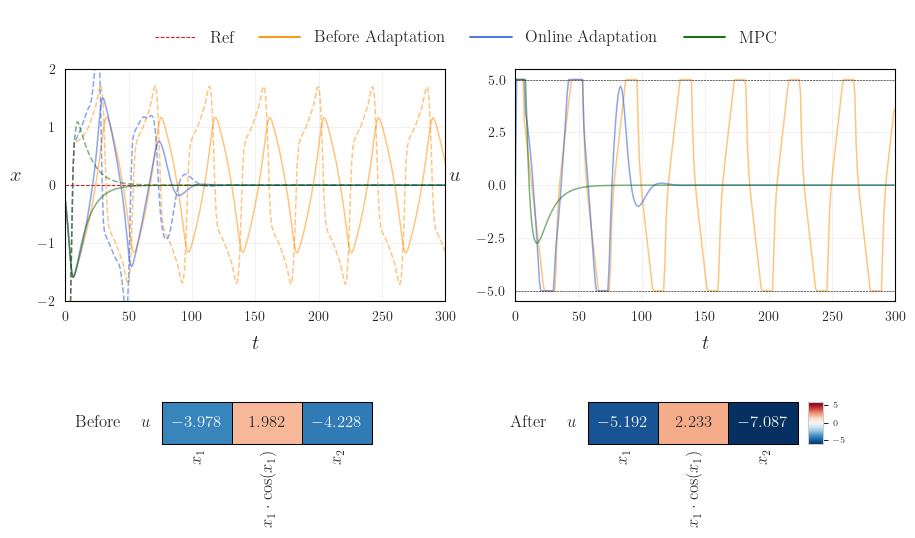

In [908]:
import importlib
import utils
importlib.reload(utils)
from utils import *
combined_controller_and_two_policy_heatmaps(
    Y_list=Y_list,
    U_list=U_list,
    controller_labels=controller_labels,
    fx_policy_SINDy=SD_SINDy_policies,
    fx_policy_WB=copy_SD_SINDy_policies,
    fx_policy_labels=[r"${u}$"],
    R=R,
    style_map=style_map,
    TS_FIG_WIDTH=10,
    TS_FIG_HEIGHT=10,
    CELL_SIZE=0.7,
    FONT_SIZE_COEFS=12,
    FONT_SIZE_COEFS_LABELS=12,
    xmin=-2.0, xmax=2.0,
    umin=-5.0, umax=5.0,
    title=None,
    save_name="results/VanDerPol_Symbolic_Adaptation.pdf"
)


In [909]:
import time, os, gc
import psutil
import torch
import numpy as np
# assumes: copy, Node, System, psl, Jmodule, jac_sym (for psi_sizes), etc. already defined

process = psutil.Process(os.getpid())

def gpu_reset():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

def gpu_read():
    if not torch.cuda.is_available():
        return 0.0, 0.0
    torch.cuda.synchronize()
    cur = torch.cuda.memory_allocated() / 1024**2  # MB
    peak = torch.cuda.max_memory_allocated() / 1024**2
    return cur, peak

times = []
gpu_peaks = []
cpu_deltas = []

for seed in range(20):
    # --- reset meters
    gpu_reset()
    cpu_before = process.memory_info().rss / 1024**2  # MB

    init_time = time.time()

    # ====== YOUR ORIGINAL CODE (unchanged logic) =======================
    copy_SD_SINDy_policies = copy.deepcopy(SD_SINDy_policies)

    vectorized_SD_SINDy_policies = VectorizedPolicy(copy_SD_SINDy_policies, umin=umin, umax=umax)
    SD_SINDy_policy_node = Node(
                lambda xn, r: vectorized_SD_SINDy_policies(xn,r),
                ['xn', 'r'], ['u'],
                name="policy_combined"
            )
    gt_sindy_policy_noisy = copy.deepcopy(System([SD_SINDy_policy_node,
                       gt_integrator_node]))

    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    np_refs = psl.signals.step(nsteps+1, 1, min=xmin+0.2, max=xmax-0.2, randsteps=5, rng=rng)
    torch_ref = torch.zeros(1, nsteps+1, nx, dtype=torch.float32, device=device)
    data = {'xn': torch.rand(1, 1, nx, dtype=torch.float32),
            'r': torch_ref}

    x_trajectory = data['xn'].detach()[:, 0, :].unsqueeze(1)
    u_trajectory = torch.zeros([1, 1, 1])
    gamma = 1.
    error_hist, f_hist = [], []

    for t in range(1, len(data['r'][0])):
        gt_sindy_policy_noisy.nsteps = 1
        next_step_data = gt_sindy_policy_noisy({
            'xn': x_trajectory[:, -1, :].unsqueeze(0),
            'r' : data['r'][:, len(x_trajectory[0]), :].unsqueeze(0)
        })

        x = next_step_data['xn'][:, -1, :].detach()
        r = next_step_data['r'][:,  -1, :].detach()
        u = vectorized_SD_SINDy_policies(x, r)

        # error and symbolic Jacobian
        e     = (r - x).reshape(-1, 1)                         # (nx, 1)
        J_sym = jac_sym(x, r, u.detach())                      # (nx, nA) or (1, nx, nA)
        if J_sym.dim() == 3:
            J_sym = J_sym.squeeze(0)                           # ensure (nx, nA)

        # normalized gradient
        Jt_e  = J_sym.T @ e                                    # (nA, 1)
        fro2  = (J_sym * J_sym).sum()                          # scalar
        denom = 1.0 + fro2
        grads_flat = (Jt_e / denom).reshape(-1)                # (nA,)

        # --- split grads per policy and reshape like p.coef ---
        per_policy_grads = []
        offset = 0
        for p, n_k in zip(copy_SD_SINDy_policies, psi_sizes):
            g_slice = grads_flat[offset:offset + n_k].view_as(p.coef)
            per_policy_grads.append(g_slice)
            offset += n_k
        assert offset == grads_flat.numel(), "grads length != sum(psi_sizes)"

        # apply updates
        update_policies(copy_SD_SINDy_policies, per_policy_grads, gamma)

        # log trajectories
        x_trajectory = torch.cat([x_trajectory, next_step_data['xn'].detach()[:, -1:, :]], dim=1)
        u_trajectory = torch.cat([u_trajectory, next_step_data['u'].detach()[:,  -1:, :]], dim=1)

        # cleanup per step to limit memory growth
        del next_step_data, J_sym, grads_flat, x, u, r, e
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    # ====== END YOUR CODE ==============================================

    end_time = time.time()
    times.append(end_time - init_time)

    # --- read meters
    cur_gpu, peak_gpu = gpu_read()
    gpu_peaks.append(peak_gpu)

    cpu_after = process.memory_info().rss / 1024**2
    cpu_deltas.append(max(0.0, cpu_after - cpu_before))  # MB increased during this seed

    # Aggressive cleanup between seeds
    del copy_SD_SINDy_policies, gt_sindy_policy_noisy, data, x_trajectory, u_trajectory
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Total time: {np.sum(times):.3f}s | Avg: {np.mean(times):.3f}s")
print(f"Peak GPU per seed (MB): mean={np.mean(gpu_peaks):.1f}, max={np.max(gpu_peaks):.1f}")
print(f"CPU ΔRSS per seed (MB): mean={np.mean(cpu_deltas):.1f}, max={np.max(cpu_deltas):.1f}")


Total time: 2.079s | Avg: 0.104s
Peak GPU per seed (MB): mean=0.0, max=0.0
CPU ΔRSS per seed (MB): mean=0.0, max=0.4
